
# DeepSea sweep visualization

This notebook loads `deepsea_results.pkl`, aggregates the per-step rewards across seeds, and visualizes the mean ± standard error for every `(reg_alpha, param_alpha)` pair.


In [8]:

import pickle
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
RESULTS_PATH = Path('freeway_results_2.pkl')
if not RESULTS_PATH.exists():
    raise FileNotFoundError('Run deeprl/ppo_deepsea.py to produce deepsea_results.pkl before visualizing.')
with RESULTS_PATH.open('rb') as fp:
    raw_records = pickle.load(fp)
print(f'Loaded {len(raw_records)} records from {RESULTS_PATH}')


Loaded 1000 records from freeway_results_2.pkl


In [9]:

from typing import Dict, Tuple

def build_groupings(records):
    grouped = defaultdict(list)
    metadata = {
        'reg_alpha': set(),
        'param_alpha': set(),
        'learning_rate': set(),
        'entropy_coeff': set(),
    }
    for rec in records:
        rewards = np.asarray(rec['rewards'])[:6250]
        key = (
            rec['reg_alpha'],
            rec['param_alpha'],
            rec['learning_rate'],
            rec['entropy_coeff'],
        )
        grouped[key].append(rewards)
        metadata['reg_alpha'].add(rec['reg_alpha'])
        metadata['param_alpha'].add(rec['param_alpha'])
        metadata['learning_rate'].add(rec['learning_rate'])
        metadata['entropy_coeff'].add(rec['entropy_coeff'])
    metadata = {k: sorted(v) for k, v in metadata.items()}
    return grouped, metadata

grouped, metadata = build_groupings(raw_records)
print('Unique values:')
for k, v in metadata.items():
    print(f'  {k}: {v}')


Unique values:
  reg_alpha: [0.1, 0.3, 0.5, 0.7, 0.9]
  param_alpha: [0.1, 0.3, 0.5, 0.7, 0.9]
  learning_rate: [0.0003000000142492354]
  entropy_coeff: [0.0010000000474974513, 0.009999999776482582]


In [10]:
grouped 

defaultdict(list,
            {(0.1,
              0.1,
              0.0003000000142492354,
              0.0010000000474974513): [array([ 0.      ,  0.      ,  0.      , ..., 26.078125, 26.078125,
                     26.078125], shape=(6250,), dtype=float32), array([ 0.      ,  0.      ,  0.      , ..., 26.640625, 26.640625,
                     26.640625], shape=(6250,), dtype=float32), array([ 0.    ,  0.    ,  0.    , ..., 26.8125, 26.8125, 26.8125],
                    shape=(6250,), dtype=float32), array([ 0.      ,  0.      ,  0.      , ..., 28.703125, 28.703125,
                     28.703125], shape=(6250,), dtype=float32), array([ 0.      ,  0.      ,  0.      , ..., 26.703125, 26.703125,
                     26.703125], shape=(6250,), dtype=float32), array([ 0.      ,  0.      ,  0.      , ..., 25.609375, 25.609375,
                     25.609375], shape=(6250,), dtype=float32), array([ 0. ,  0. ,  0. , ..., 29.5, 29.5, 29.5],
                    shape=(6250,), dtype=float

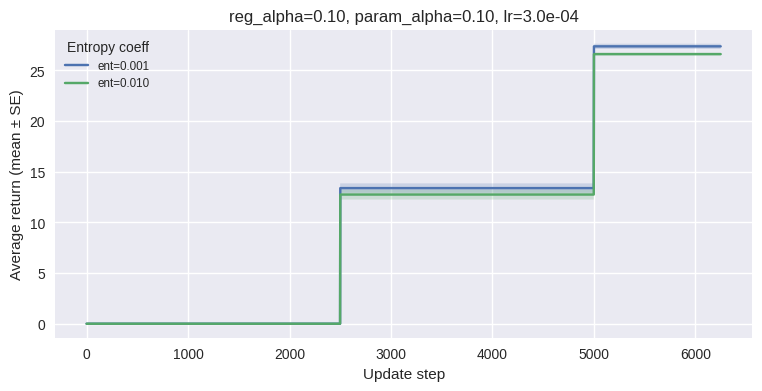

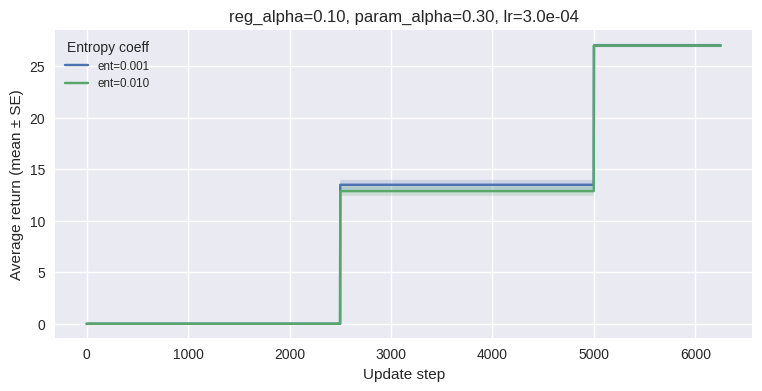

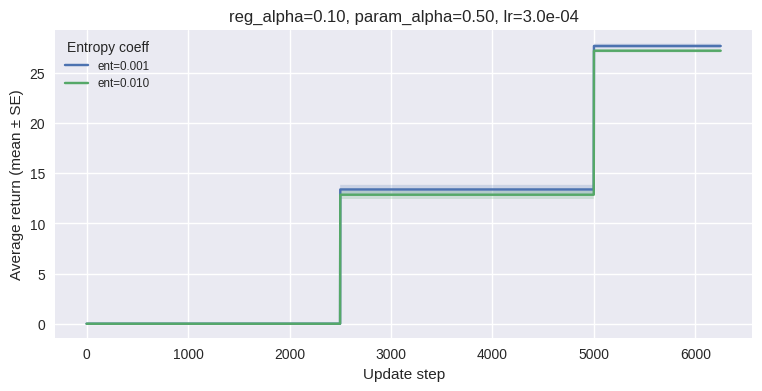

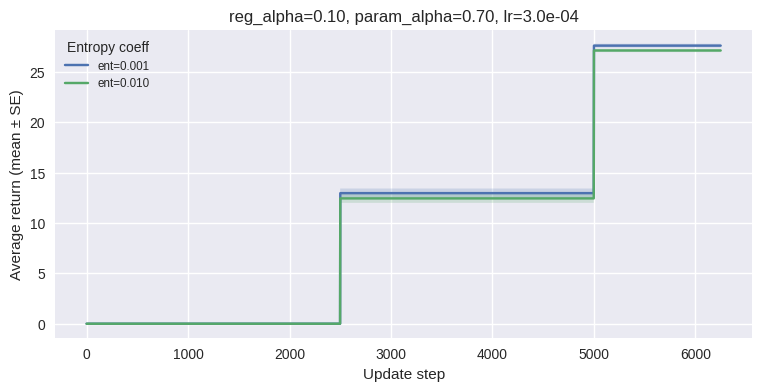

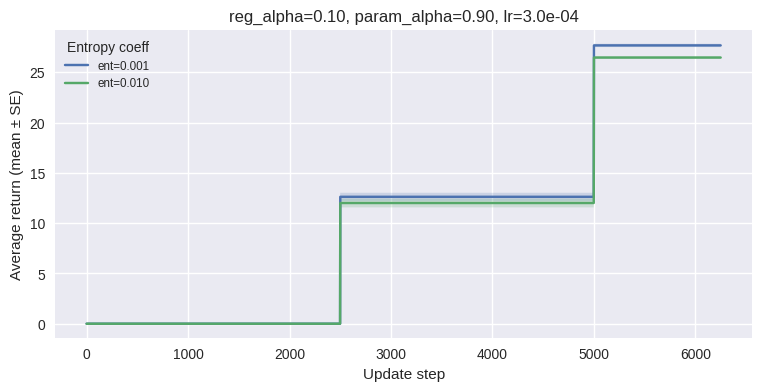

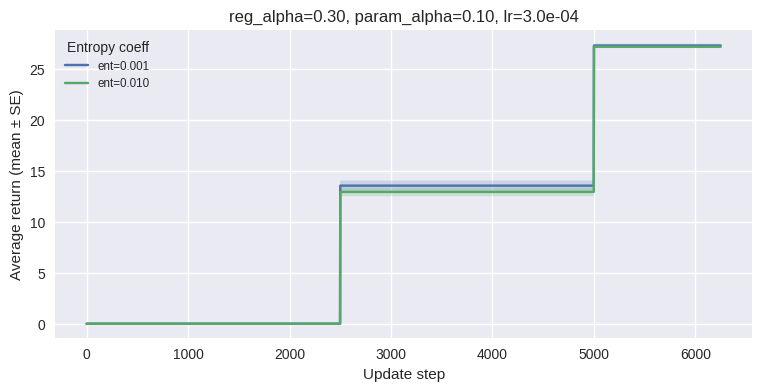

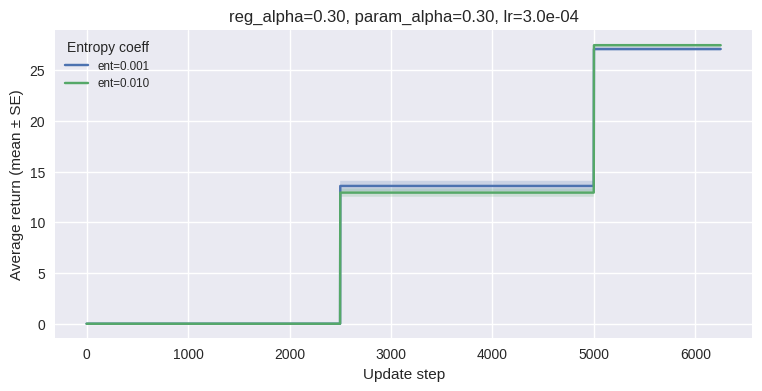

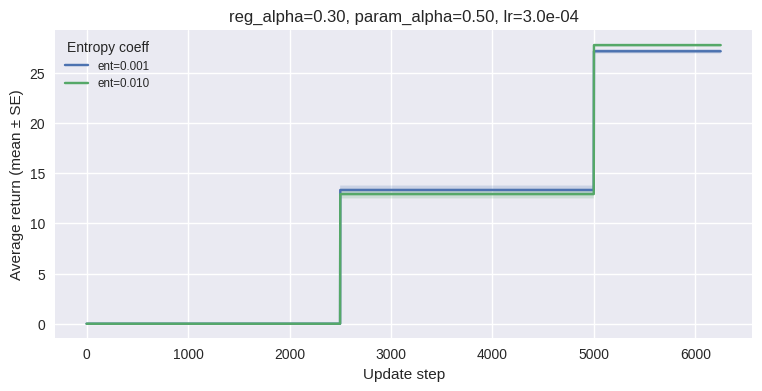

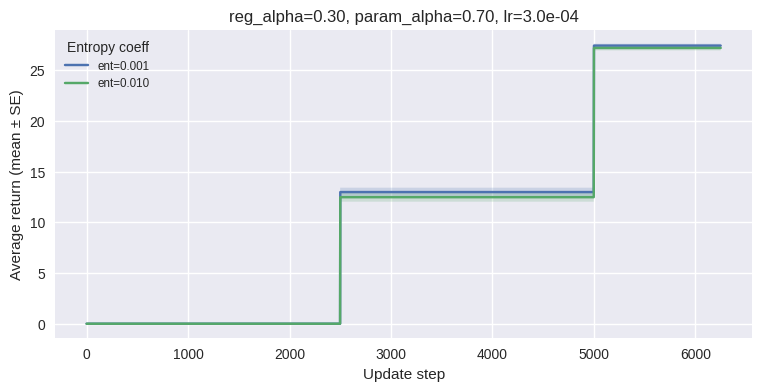

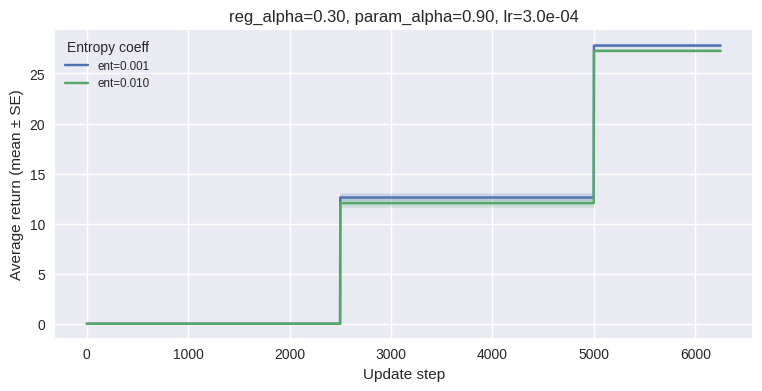

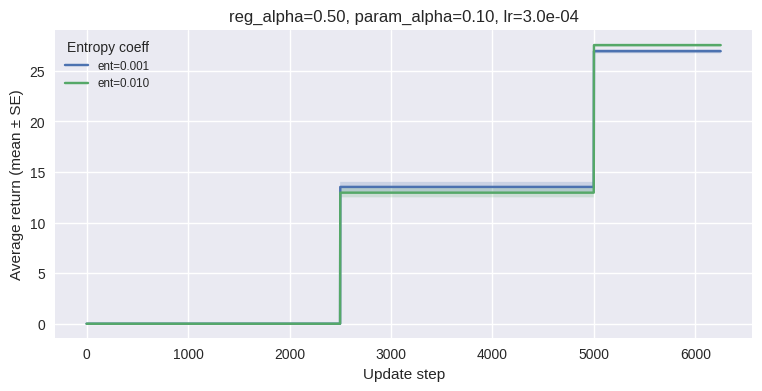

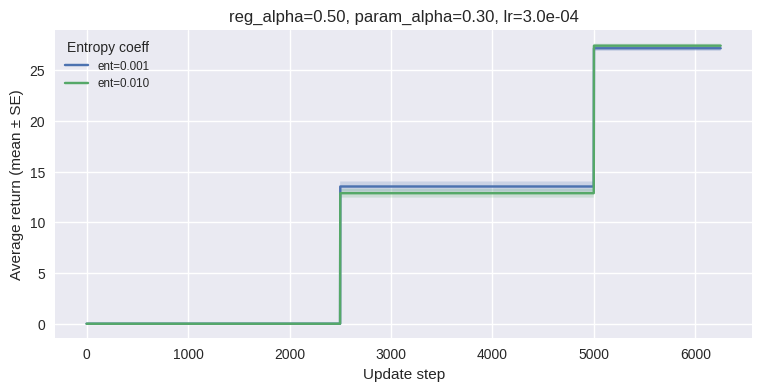

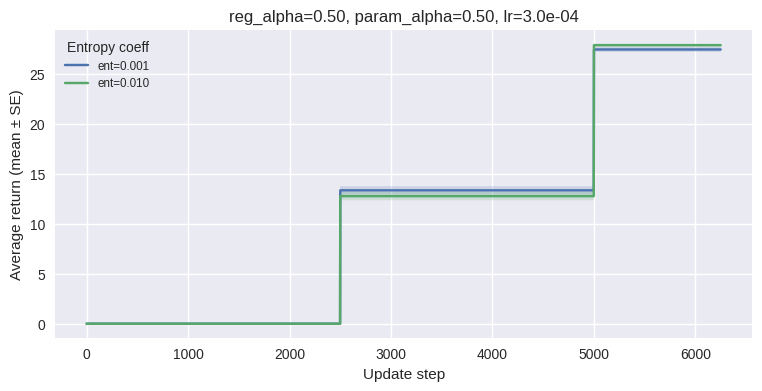

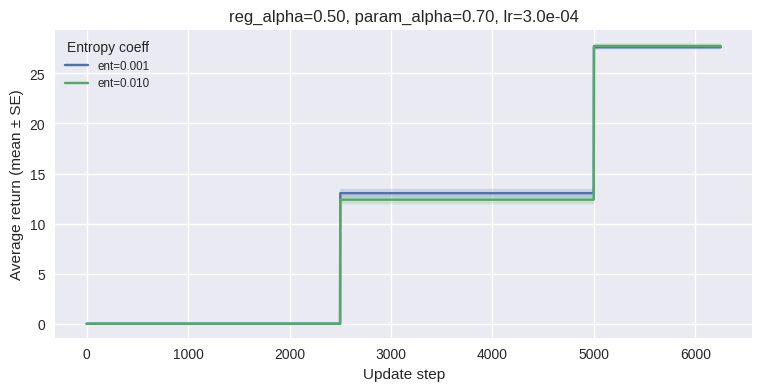

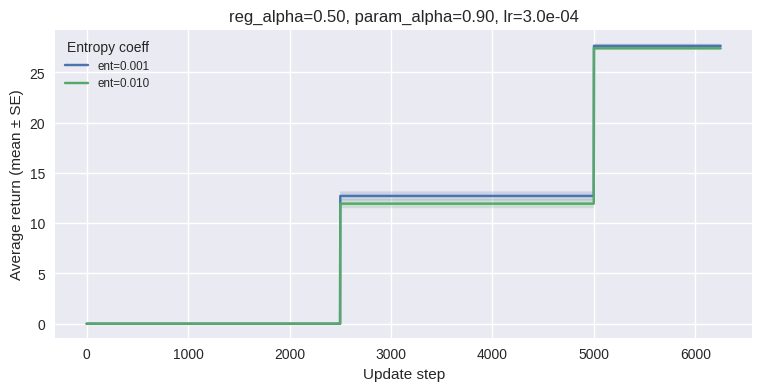

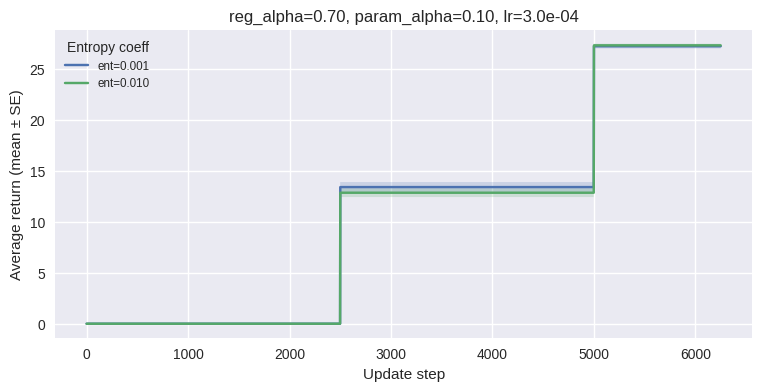

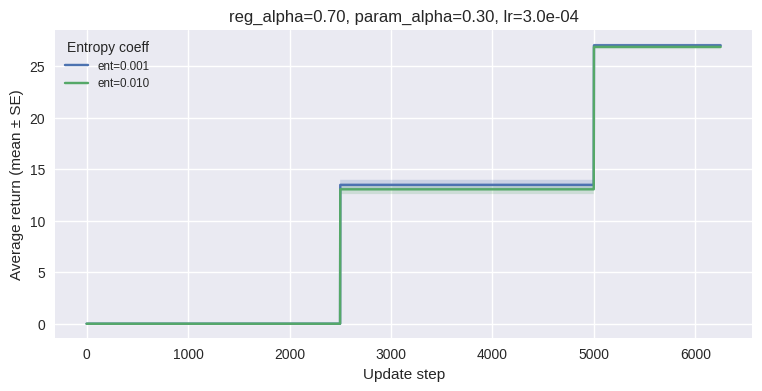

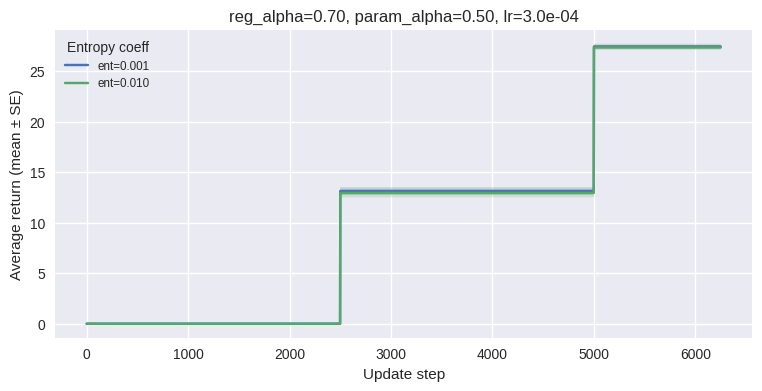

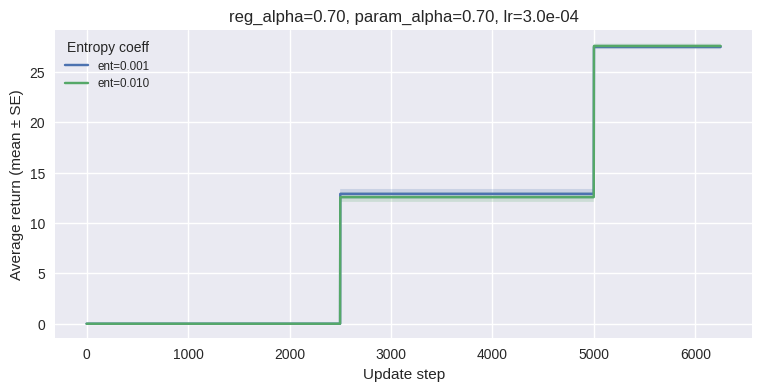

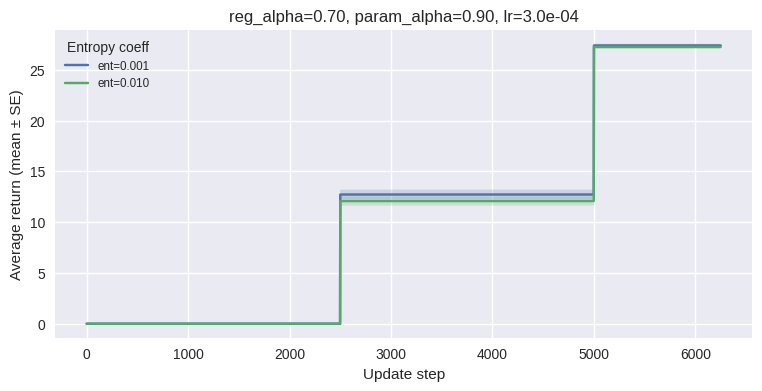

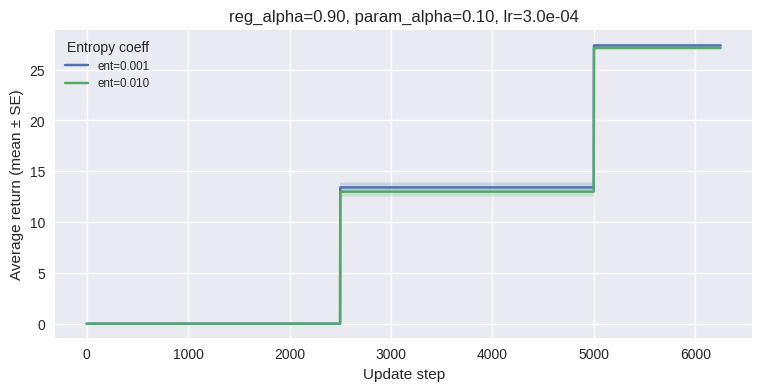

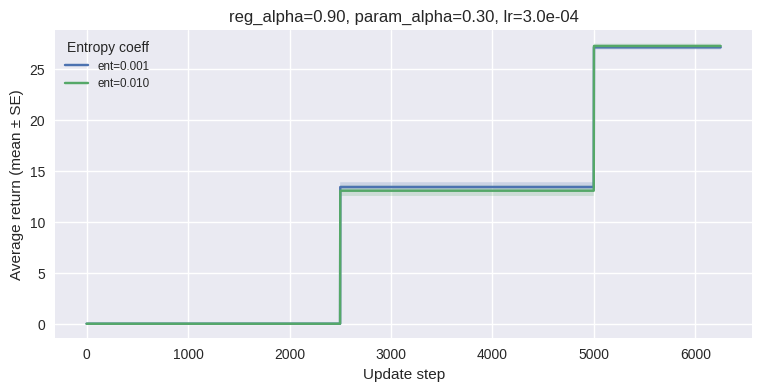

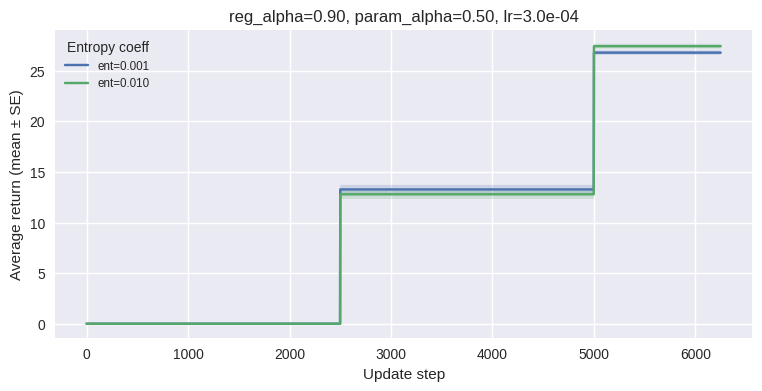

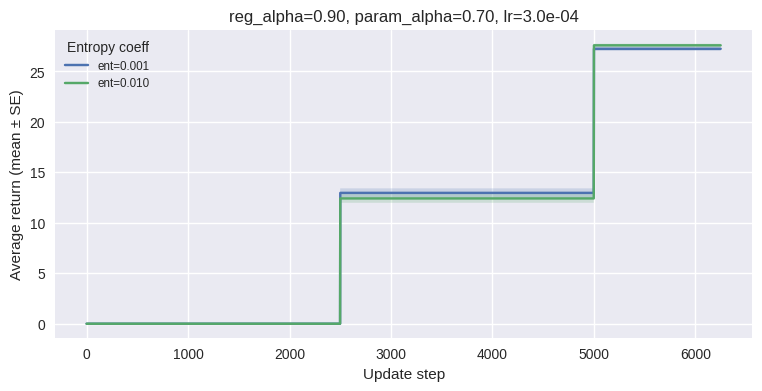

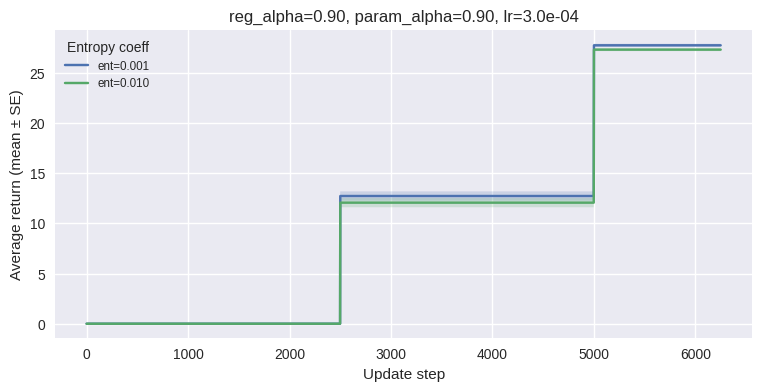

In [11]:

import math

best_curves = {}

def summarize_runs(run_list):
    arr = np.stack(run_list)
    mean = arr.mean(axis=0)
    if arr.shape[0] > 1:
        std = arr.std(axis=0, ddof=1)
    else:
        std = np.zeros_like(mean)
    se = std / math.sqrt(arr.shape[0]) if arr.shape[0] > 0 else std
    return mean, se

for reg_alpha in metadata['reg_alpha']:
    for param_alpha in metadata['param_alpha']:
        pair_best_score = None
        pair_best_entry = None
        for lr in metadata['learning_rate']:
            fig, ax = plt.subplots(figsize=(9, 4))
            lr_has_data = False
            for entropy in metadata['entropy_coeff']:
                key = (reg_alpha, param_alpha, lr, entropy)
                if key not in grouped:
                    continue
                mean, se = summarize_runs(grouped[key])
                x = np.arange(mean.shape[0])
                label = f"ent={entropy:.3f}"
                ax.plot(x, mean, label=label)
                ax.fill_between(x, mean - se, mean + se, alpha=0.2)
                lr_has_data = True
                final_score = mean[-100:].mean()
                if pair_best_score is None or final_score > pair_best_score:
                    pair_best_score = final_score
                    pair_best_entry = {
                        'mean': mean,
                        'se': se,
                        'lr': lr,
                        'entropy': entropy,
                        'x': x,
                    }
            if lr_has_data:
                ax.set_title(f"reg_alpha={reg_alpha:.2f}, param_alpha={param_alpha:.2f}, lr={lr:.1e}")
                ax.set_xlabel('Update step')
                ax.set_ylabel('Average return (mean ± SE)')
                ax.legend(loc='best', fontsize='small', title='Entropy coeff')
                plt.show()
            else:
                plt.close(fig)
        if pair_best_entry is not None:
            best_curves[(reg_alpha, param_alpha)] = pair_best_entry


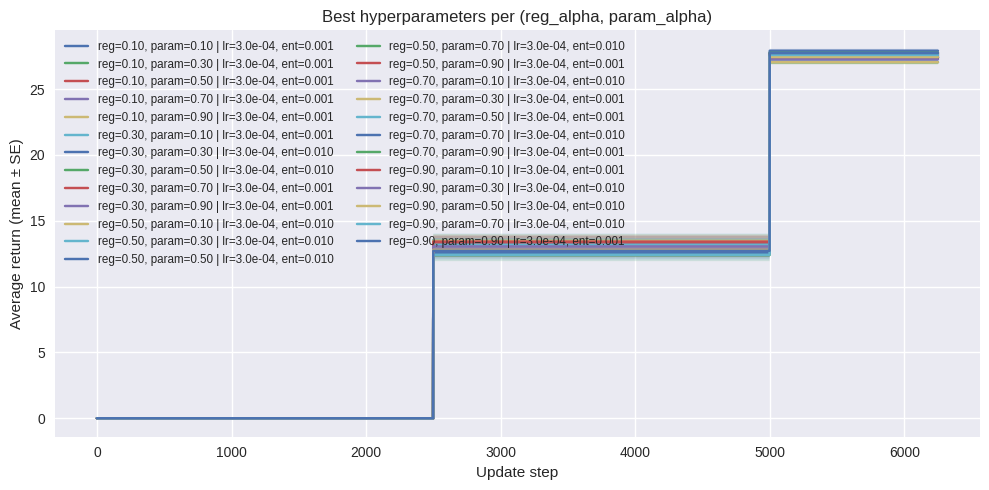

,reg_alpha,param_alpha,learning_rate,entropy_coeff,final_mean_return
0,0.1,0.1,0.0003,0.001,27.374218
1,0.1,0.3,0.0003,0.001,27.033594
2,0.1,0.5,0.0003,0.001,27.696875
3,0.1,0.7,0.0003,0.001,27.613281
4,0.1,0.9,0.0003,0.001,27.664845
5,0.3,0.1,0.0003,0.001,27.283594
6,0.3,0.3,0.0003,0.010,27.464844
7,0.3,0.5,0.0003,0.010,27.753906
8,0.3,0.7,0.0003,0.001,27.408594
9,0.3,0.9,0.0003,0.001,27.789845


In [12]:

if not best_curves:
    raise RuntimeError('No curves available to summarize. Verify the pickle contents.')

fig, ax = plt.subplots(figsize=(10, 5))
summary_rows = []
for (reg_alpha, param_alpha), stats in best_curves.items():
    mean = stats['mean']
    se = stats['se']
    x = stats['x']
    lr = stats['lr']
    entropy = stats['entropy']
    label = f"reg={reg_alpha:.2f}, param={param_alpha:.2f} | lr={lr:.1e}, ent={entropy:.3f}"
    ax.plot(x, mean, label=label)
    ax.fill_between(x, mean - se, mean + se, alpha=0.15)
    summary_rows.append({
        'reg_alpha': reg_alpha,
        'param_alpha': param_alpha,
        'learning_rate': lr,
        'entropy_coeff': entropy,
        'final_mean_return': mean[-1],
    })

ax.set_title('Best hyperparameters per (reg_alpha, param_alpha)')
ax.set_xlabel('Update step')
ax.set_ylabel('Average return (mean ± SE)')
ax.legend(loc='best', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows).sort_values(['reg_alpha', 'param_alpha'])
display(summary_df)


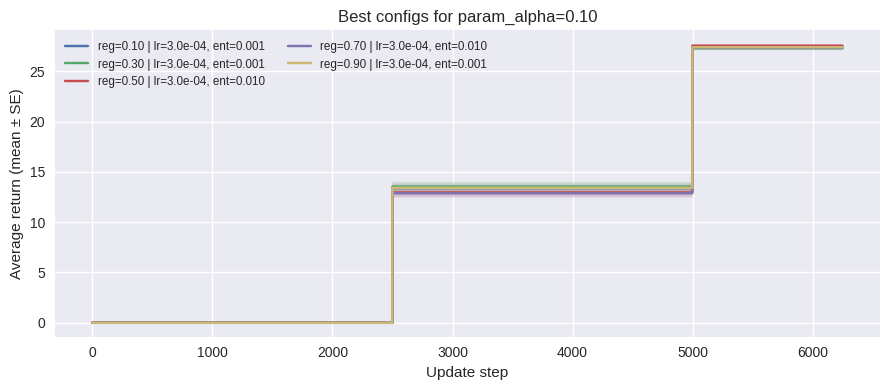

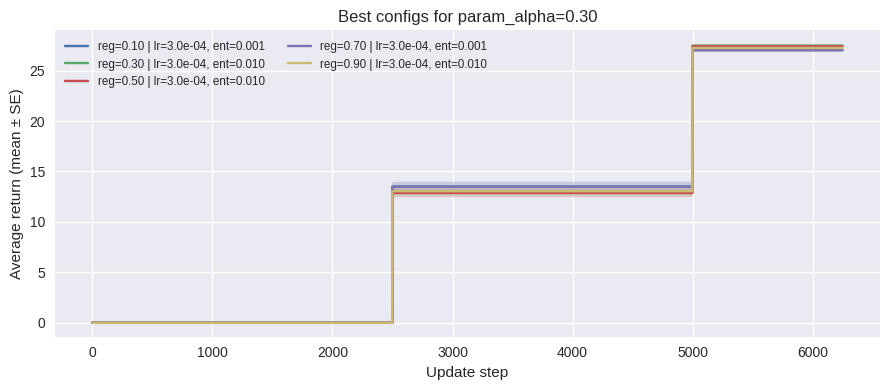

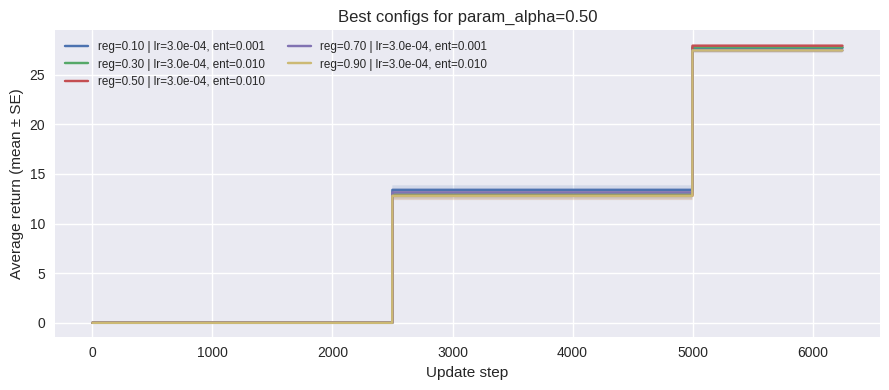

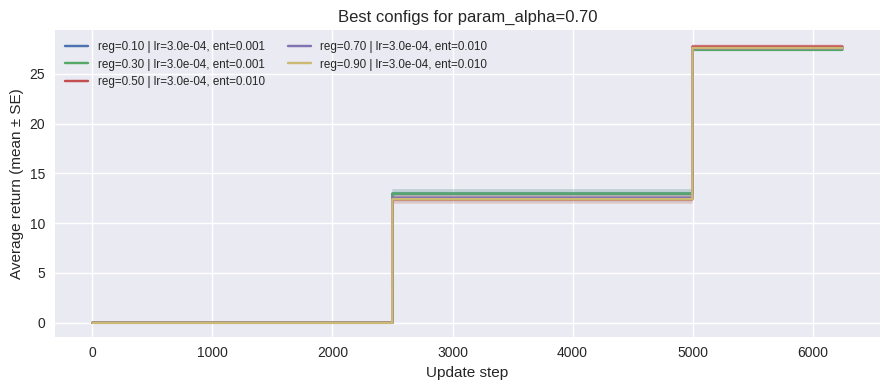

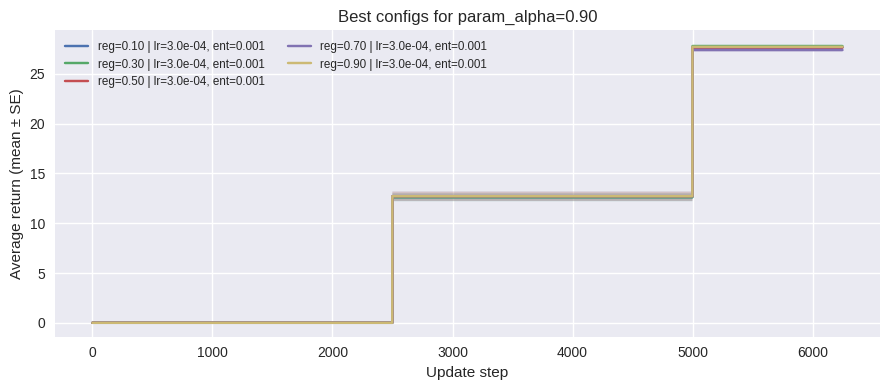

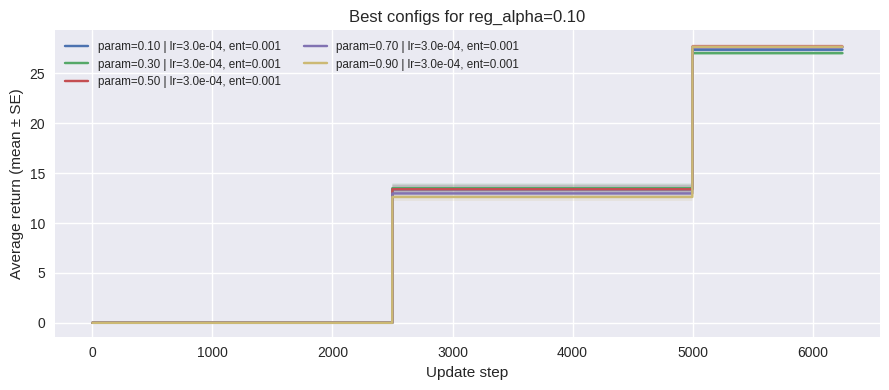

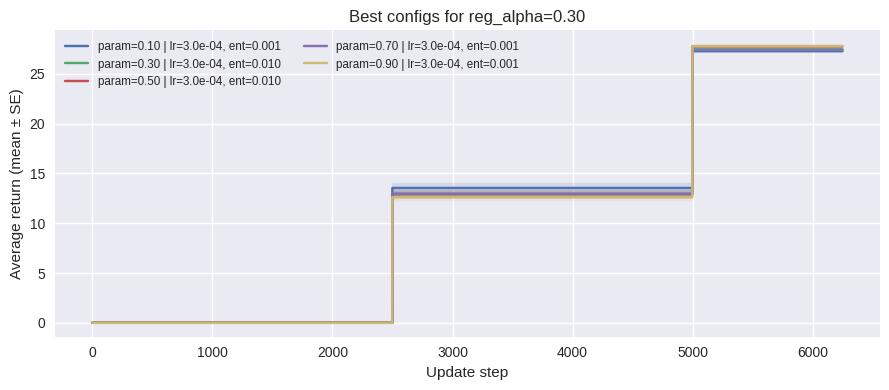

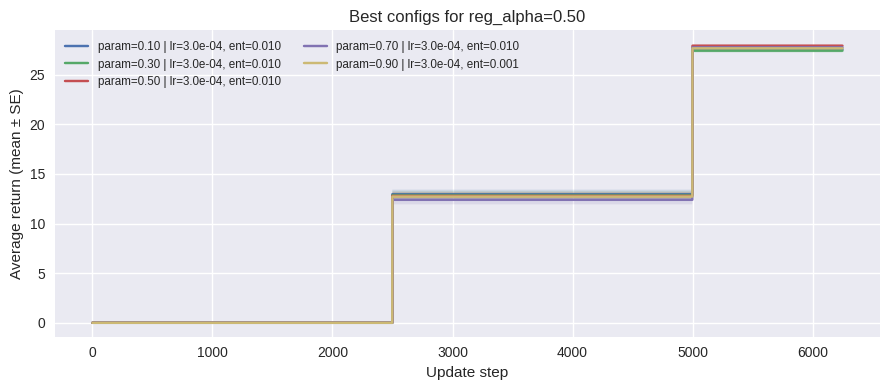

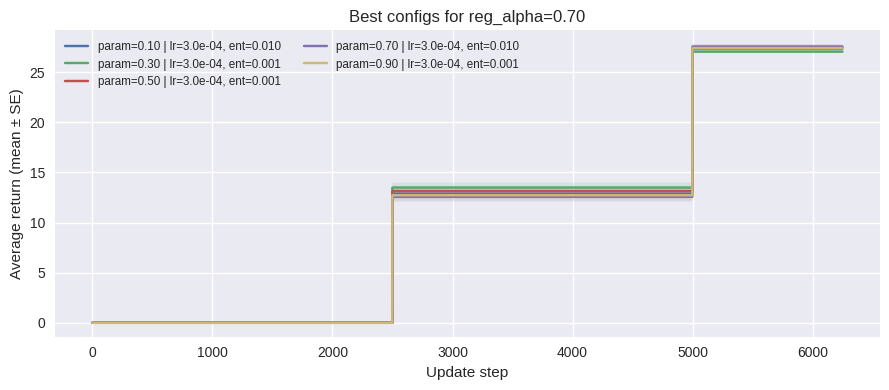

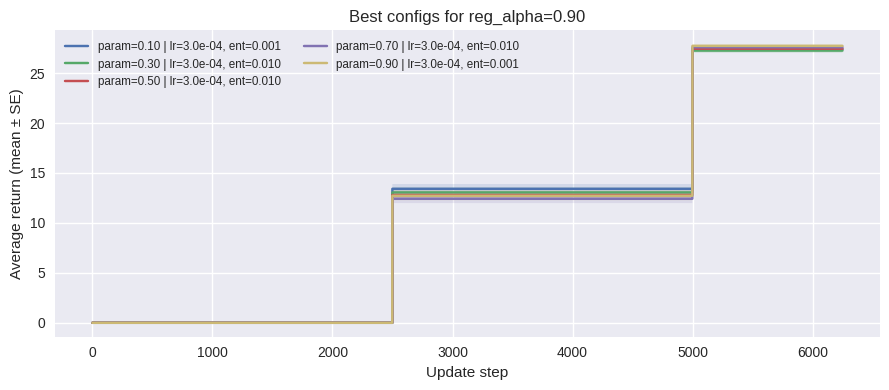

In [13]:

from collections import defaultdict

param_groups = defaultdict(list)
reg_groups = defaultdict(list)
for (reg_alpha, param_alpha), stats in best_curves.items():
    param_groups[param_alpha].append((reg_alpha, stats))
    reg_groups[reg_alpha].append((param_alpha, stats))

for param_alpha, entries in sorted(param_groups.items()):
    fig, ax = plt.subplots(figsize=(9, 4))
    for reg_alpha, stats in sorted(entries, key=lambda x: x[0]):
        mean = stats['mean']
        se = stats['se']
        x = stats['x']
        lr = stats['lr']
        entropy = stats['entropy']
        label = f"reg={reg_alpha:.2f} | lr={lr:.1e}, ent={entropy:.3f}"
        ax.plot(x, mean, label=label)
        ax.fill_between(x, mean - se, mean + se, alpha=0.15)
    ax.set_title(f"Best configs for param_alpha={param_alpha:.2f}")
    ax.set_xlabel('Update step')
    ax.set_ylabel('Average return (mean ± SE)')
    ax.legend(loc='best', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

for reg_alpha, entries in sorted(reg_groups.items()):
    fig, ax = plt.subplots(figsize=(9, 4))
    for param_alpha, stats in sorted(entries, key=lambda x: x[0]):
        mean = stats['mean']
        se = stats['se']
        x = stats['x']
        lr = stats['lr']
        entropy = stats['entropy']
        label = f"param={param_alpha:.2f} | lr={lr:.1e}, ent={entropy:.3f}"
        ax.plot(x, mean, label=label)
        ax.fill_between(x, mean - se, mean + se, alpha=0.15)
    ax.set_title(f"Best configs for reg_alpha={reg_alpha:.2f}")
    ax.set_xlabel('Update step')
    ax.set_ylabel('Average return (mean ± SE)')
    ax.legend(loc='best', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()


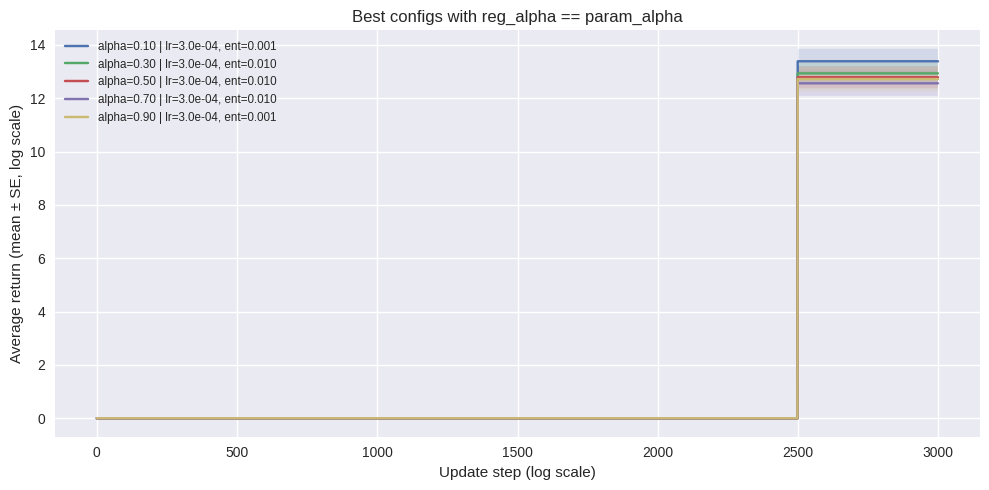

,alpha,learning_rate,entropy_coeff,final_mean_return
0,0.1,0.0003,0.001,13.383594
1,0.3,0.0003,0.010,12.930469
2,0.5,0.0003,0.010,12.785156
3,0.7,0.0003,0.010,12.557813
4,0.9,0.0003,0.001,12.717188


In [ ]:

import numpy as np

diag_stats = [((reg_alpha, param_alpha), stats)
               for (reg_alpha, param_alpha), stats in best_curves.items()
               if np.isclose(reg_alpha, param_alpha)]
if not diag_stats:
    raise RuntimeError('No entries found with reg_alpha == param_alpha.')

fig, ax = plt.subplots(figsize=(10, 5))
diag_rows = []
for (reg_alpha, param_alpha), stats in diag_stats:
    mean = stats['mean'][:3000]
    se = stats['se'][:3000]
    x = stats['x'][:3000]
    lr = stats['lr']
    entropy = stats['entropy']
    label = f"alpha={reg_alpha:.2f} | lr={lr:.1e}, ent={entropy:.3f}"
    ax.plot(x, mean, label=label)
    ax.fill_between(x, mean - se, mean + se, alpha=0.15)
    diag_rows.append({
        'alpha': reg_alpha,
        'learning_rate': lr,
        'entropy_coeff': entropy,
        'final_mean_return': mean[-1],
    })

ax.set_title('Best configs with reg_alpha == param_alpha')
#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel('Update step')
ax.set_ylabel('Average return (mean ± SE)')
ax.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

diag_df = pd.DataFrame(diag_rows).sort_values('alpha')
display(diag_df)
